# Model multi producer networks

## Initialization of all needed packages
Pandapipes is needed in its latest developer version

In [1]:
import pandapipes as pp
import pandapipes.plotting as plot
from pandapipes.timeseries import run_time_series
from pandapower.control.basic_controller import BasicCtrl
from pandapower.timeseries import OutputWriter
from math import pi
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

## Initialization of junctions and pipes
The initialization temperature and pressure theoretically have no impact on the final result. However, if they are not picked carefully, this can lead to convergence problems. Usually, it works best to set them to the supply temperature.

In [2]:
net = pp.create_empty_network(fluid= 'water')

########################################################## Junction ###################################################################
t_supply_init = 80 + 273.15  #in K
t_return_init = 60 + 273.15  #in K
p_init = 20 #bar #initial pressure

# supply junctions
j0 = pp.create_junction(net, pn_bar = p_init, tfluid_k = t_supply_init, geodata=(1,0), name='j0')
j1 = pp.create_junction(net, pn_bar = p_init, tfluid_k = t_supply_init, geodata=(1,-1), name='j1')
j2 = pp.create_junction(net, pn_bar = p_init, tfluid_k = t_supply_init, geodata=(1,-2), name='j2')
j3 = pp.create_junction(net, pn_bar = p_init, tfluid_k = t_supply_init, geodata=(1,-3), name='j3')
# return junctions
j4 = pp.create_junction(net, pn_bar = p_init, tfluid_k = t_return_init, geodata=(-1,-3), name='j4')
j5 = pp.create_junction(net, pn_bar = p_init, tfluid_k = t_return_init, geodata=(-1,-2), name='j5')
j6 = pp.create_junction(net, pn_bar = p_init, tfluid_k = t_return_init, geodata=(-1,-1), name='j6')
j7 = pp.create_junction(net, pn_bar = p_init, tfluid_k = t_return_init, geodata=(-1,0), name='j7')
# intermediate
j25 = pp.create_junction(net, pn_bar = p_init, tfluid_k = t_supply_init, geodata=(0,-2), name='j25')

########################################################## Pipes ###################################################################
friction = 0.01
alpha = 0.5
diameter_m = 0.03
t_ground = 273.15+ 10
# supply pipes
pipe0 = pp.create_pipe_from_parameters(net, from_junction= j0, to_junction= j1, length_km = 1, diameter_m= diameter_m, k_mm= friction,sections=10, alpha_w_per_m2k= alpha, text_k= t_ground, name= 'pipe0_1')
pipe1 = pp.create_pipe_from_parameters(net, from_junction= j1, to_junction= j2, length_km = 1, diameter_m= diameter_m, k_mm= friction,sections=10, alpha_w_per_m2k= alpha, text_k= t_ground, name= 'pipe1_2')
pipe2 = pp.create_pipe_from_parameters(net, from_junction= j2, to_junction= j3, length_km = 1, diameter_m= diameter_m, k_mm= friction,sections=10, alpha_w_per_m2k= alpha, text_k= t_ground, name= 'pipe2_3')
# return pipes
pipe3 = pp.create_pipe_from_parameters(net, from_junction= j4, to_junction= j5, length_km = 1, diameter_m= diameter_m, k_mm= friction,sections=10, alpha_w_per_m2k= alpha, text_k= t_ground, name= 'pipe4_5')
pipe4 = pp.create_pipe_from_parameters(net, from_junction= j5, to_junction= j6, length_km = 1, diameter_m= diameter_m, k_mm= friction,sections=10, alpha_w_per_m2k= alpha, text_k= t_ground, name= 'pipe5_6')
pipe5 = pp.create_pipe_from_parameters(net, from_junction= j6, to_junction= j7, length_km = 1, diameter_m= diameter_m, k_mm= friction,sections=10, alpha_w_per_m2k= alpha, text_k= t_ground, name= 'pipe6_7')


## Create heat consumers
There is three options how heat_consumers can be modelled. For multi producer networks, where supply temperature may be varying due to variable dispatch schedules and supply temperatures at the related producers, the "best guess" is to fix the heat and return temperature. Fixing the mass flow is usually more robust and can also be sufficient is certain cases.

In [3]:
t_return_k_cons1 = t_return_init
cons1 = pp.create_heat_consumer(net,
                                from_junction=j1,
                                to_junction=j6,
                                name = 'consumer1',
                                qext_w= 40000,
                                #controlled_mdot_kg_per_s= 0.3,  # controlled mass flow rate through the heat exchanger to fulfil demand
                                treturn_k= t_return_k_cons1,  # controlled return temperature of the consumer
                                #deltat_k=30,  # controlled temperature difference between supply and return junction of the consumer
                                )
t_return_k_cons2 = t_return_init
cons2 = pp.create_heat_consumer(net,
                                from_junction=j3,
                                to_junction=j4,
                                name = 'consumer2',
                                qext_w= 40000,
                                #controlled_mdot_kg_per_s= 0.3,
                                treturn_k= t_return_k_cons2, 
                                #deltat_k=30,
                                )


## Create producers
In pandapipes, the pumps act as producers. The supply temperature is set here and defines the power that is added to the system. In any network one "pressure pump" (circ_pump_const_pressure) is needed. The supply temperature is defined, the power and mass flow are a result of the energy balance of the overall system. If there are additional producers, they currently have to be modelled with two seperate components, a mass pump (circ_pump_const_mass) and flow control component. Here, supply temperature and mass flow need to be defined. The power can be approximately defined at this producer by assuming a return temperature. However, the actual return temperature that will result at the pump entrance is unknown at this point. 

The level of the system pressure is defined with the parameter p_flow_bar at the pressure pump (the outlet pressure). p_flow_bar and pressure lift in this example can be considered only an initial value as it will later be optimized with a controller. However, the controller will keep the inital difference of flow pressure and pressure lift constant, so the final inlet pressure of the pressure pump is indirectly given with these two values.
The pressure given at the mass pump is only an initial value. Important: For the evaluation of the flow pressure behind the mass pump, always the pressure at the outlet of the flow control component should be evaluated!

In [4]:
#Producer 1 (is always needed): pressure pump
T_supply_c_producer1 = 273.15+ 80
prod = pp.create_circ_pump_const_pressure(net, name = 'primary_pump',return_junction= j7, flow_junction= j0, p_flow_bar= 20, plift_bar= 10, t_flow_k = T_supply_c_producer1)

#Producer 2 (for multi source system): mass pump and flow control
T_supply_c_producer2 = 273.15+ 80
Qdot_producer2_w = 20000
mdot_flow_kg_per_s = Qdot_producer2_w / (4190 * (T_supply_c_producer2 - t_return_init))
prod2 = pp.create_circ_pump_const_mass_flow(net, name = 'secondary_pump', return_junction= j5, flow_junction= j25, p_flow_bar= 20, mdot_flow_kg_per_s= mdot_flow_kg_per_s, t_flow_k = T_supply_c_producer2, type = 'auto')
pp.create_flow_control(net, name = 'secondary_pump', from_junction= j25,to_junction= j2,control_active= True,controlled_mdot_kg_per_s=mdot_flow_kg_per_s,diameter_m= 0.025)


diameter_m is deprecated as it has no effect on the calculation and results. Nonetheless, it will be stored in the compoent table for postprocessing purposes by you if required.


np.int64(0)

## Define Outputwriter
This is relevant for time series simulations. Time series simulations are needed when controllers shall be integrated into the calulcation.

In [5]:
def define_output_writer(net, timesteps = range(1), path=None):
    log_variables = [('res_junction', 'p_bar'),
                    ('res_junction', 't_k'), 
                    ('res_pipe', 'v_mean_m_per_s'),
                    ('res_heat_consumer', 'qext_w'),
                    ('res_heat_consumer', 't_to_k'),
                    ('res_heat_consumer', 't_from_k'),
                    ('res_heat_consumer', 'p_from_bar'),
                    ('res_heat_consumer', 'p_to_bar'),
                    ('res_circ_pump_pressure', 'mdot_to_kg_per_s'), 
                    ('res_circ_pump_pressure', 'p_from_bar'),
                    ('res_circ_pump_pressure', 'p_to_bar'),
                    ('res_heat_consumer', 'mdot_from_kg_per_s'),
                    ('res_circ_pump_mass', 'mdot_to_kg_per_s'),
                    ('res_circ_pump_mass', 'p_from_bar'),
                    ('res_circ_pump_mass', 'p_to_bar'),
                    ('res_flow_control', 'p_from_bar'), 
                    ('res_flow_control', 'p_to_bar'),
                    ('res_flow_control', 'mdot_to_kg_per_s')
                    ]
    ow = OutputWriter(net, timesteps, output_path=None, log_variables=log_variables)
    return ow

## Define Differential pressure controller
The differential pressure controller performs several pipeflows until the pressure lift and outlet pressure at the pressure pump is reached that leads to the intended pressure lift at the worst point of the network (the consumer with the lowest pressure difference). The inlet pressure will remain at the inital difference of flow pressure and pressure lift.

In [6]:
class BadPointPressureLiftController(BasicCtrl):
    """
    A controller for maintaining the pressure difference at the worst point (German: Differenzdruckregelung im Schlechtpunkt) in the network.
    Author: Jonas Pfeiffer
    Args:
        net (pandapipesNet): The pandapipes network.
        circ_pump_pressure_idx (int, optional): Index of the circulation pump. Defaults to 0.
        target_dp_min_bar (float, optional): Target minimum pressure difference in bar. Defaults to 1.
        tolerance (float, optional): Tolerance for pressure difference. Defaults to 0.2.
        proportional_gain (float, optional): Proportional gain for the controller. Defaults to 0.2.
        min_plift (float, optional): Minimum lift pressure in bar. Defaults to 1.5.
        min_pflow (float, optional): Minimum flow pressure in bar. Defaults to 3.5.
        **kwargs: Additional keyword arguments.
    """
    def __init__(self, net, circ_pump_pressure_idx=0, target_dp_min_bar=1, tolerance=0.2, proportional_gain=0.2, min_plift=1.5, min_pflow=3.5, **kwargs):
        super(BadPointPressureLiftController, self).__init__(net, **kwargs)
        self.circ_pump_pressure_idx = circ_pump_pressure_idx
        self.target_dp_min_bar = target_dp_min_bar
        self.tolerance = tolerance
        self.proportional_gain = proportional_gain

        self.min_plift = min_plift  # Minimum pressure in bar
        self.min_pflow = min_pflow  # Minimum lift pressure in bar

        self.iteration = 0  # Add iteration counter

        # Initial pipeflow calculation
        pp.pipeflow(net, iter = 5000, mode="hydraulics")
        print('Initial pipeflow calculation was sucessful')
        self.dp_min, self.heat_consumer_idx = self.calculate_worst_point(net)

    @staticmethod
    def calculate_worst_point(net):
        """Calculate the worst point in the heating network, defined as the heat exchanger with the lowest pressure difference.

        Args:
            net (pandapipesNet): The pandapipes network.

        Returns:
            tuple: The minimum pressure difference and the index of the worst point.
        """
        
        dp = []

        for idx, qext, p_from, p_to in zip(net.heat_consumer.index, net.heat_consumer["qext_w"], net.res_heat_consumer["p_from_bar"], net.res_heat_consumer["p_to_bar"]):
            if qext != 0:
                dp_diff = p_from - p_to
                dp.append((dp_diff, idx))

        if not dp:
            return 0, -1

        # Find the minimum delta p where the heat flow is not zero
        dp_min, idx_min = min(dp, key=lambda x: x[0])

        return dp_min, idx_min

    def time_step(self, net, time_step):
        """Reset the iteration counter at the start of each time step.

        Args:
            net (pandapipesNet): The pandapipes network.
            time_step (int): The current time step.

        Returns:
            int: The current time step.
        """
        self.iteration = 0  # reset iteration counter
        self.dp_min, self.heat_consumer_idx = self.calculate_worst_point(net)

        return time_step

    def is_converged(self, net):
        """Check if the controller has converged.

        Args:
            net (pandapipesNet): The pandapipes network.

        Returns:
            bool: True if converged, False otherwise.
        """

        if all(net.heat_consumer["qext_w"] == 0):
            return True
        
        current_dp_bar = net.res_heat_consumer.loc[self.heat_consumer_idx, "p_from_bar"] - net.res_heat_consumer.loc[self.heat_consumer_idx, "p_to_bar"]

        # Check if the pressure difference is within tolerance
        dp_within_tolerance = abs(current_dp_bar - self.target_dp_min_bar) < self.tolerance
        #print(net.res_heat_consumer.loc[self.heat_consumer_idx, "p_from_bar"])
        #print(net.res_heat_consumer.loc[self.heat_consumer_idx, "p_to_bar"])
        #print(dp_within_tolerance)

        if dp_within_tolerance == True:
            return dp_within_tolerance

    def control_step(self, net):
        """Adjust the pump pressure to maintain the target pressure difference.

        Args:
            net (pandapipesNet): The pandapipes network.
        """
        # Increment iteration counter
        self.iteration += 1

        """Adjust the pump pressure or switch to standby mode when heat flow is zero."""
        if all(net.heat_consumer["qext_w"] == 0):
            # Switch to standby mode
            print("No heat flow detected. Switching to standby mode.")
            net.circ_pump_pressure["plift_bar"].iloc[:] = self.min_plift  # Minimum lift pressure
            net.circ_pump_pressure["p_flow_bar"].iloc[:] = self.min_pflow  # Minimum flow pressure
            return super(BadPointPressureLiftController, self).control_step(net)

        # Check whether the heat flow in the heat exchanger is zero
        current_dp_bar = net.res_heat_consumer.loc[self.heat_consumer_idx, "p_from_bar"] - net.res_heat_consumer.loc[self.heat_consumer_idx, "p_to_bar"]
        current_plift_bar = net.circ_pump_pressure.loc[self.circ_pump_pressure_idx, "plift_bar"]
        current_pflow_bar = net.circ_pump_pressure.loc[self.circ_pump_pressure_idx, "p_flow_bar"]

        dp_error = self.target_dp_min_bar - current_dp_bar
        
        plift_adjustment = dp_error * self.proportional_gain
        pflow_adjustment = dp_error * self.proportional_gain        

        new_plift = current_plift_bar + plift_adjustment
        new_pflow = current_pflow_bar + pflow_adjustment
        

        net.circ_pump_pressure.loc[self.circ_pump_pressure_idx, "plift_bar"] = new_plift
        net.circ_pump_pressure.loc[self.circ_pump_pressure_idx, "p_flow_bar"] = new_pflow

        return super(BadPointPressureLiftController, self).control_step(net)

## Plot network structure

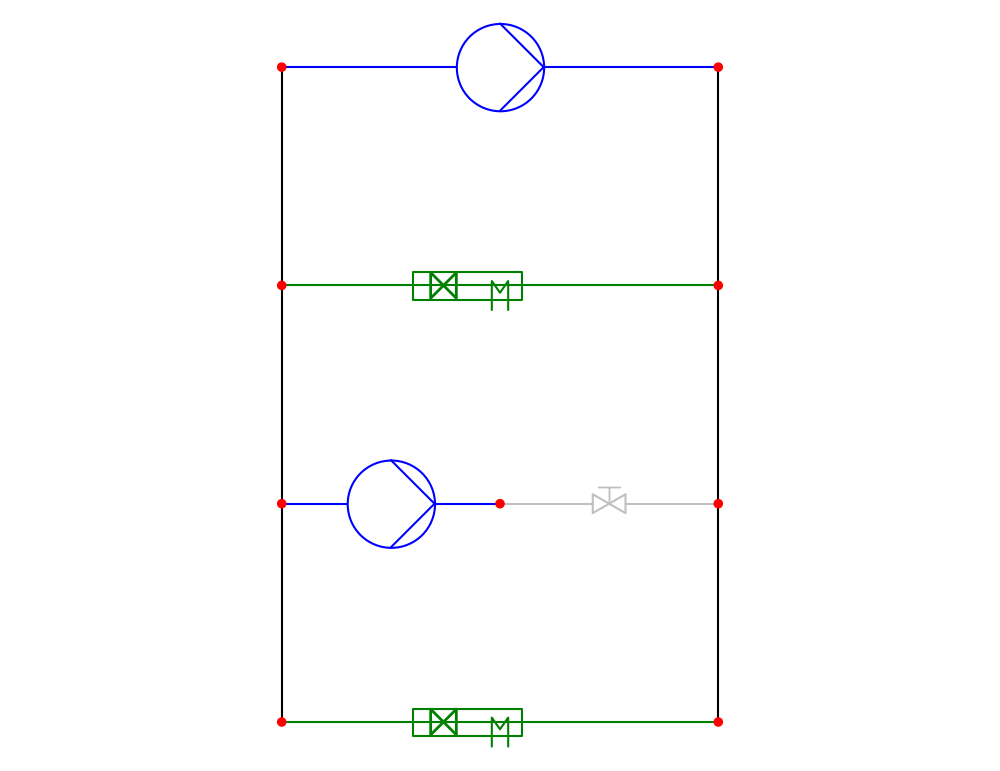

<Axes: >

In [7]:
plot.simple_plot(net,
                junction_color= 'r',
                junction_size= 0.75,
                pipe_color= 'k',
                pipe_width= 1.5,
                pump_color= 'b',
                pump_size= 1,
                heat_consumer_color= 'green',
                heat_consumer_size= 2
)

## Run time series simulation
In order to integrate the differential pressure controller, time series simulation modelling is necessary. An example for one time step is shown below. Bidirectional mode needs to be picked in order to solve the heat consumers by heat and return temperature.

In [8]:
# Set timesteps to calculate only one timestep
timesteps = range(1)

# Define outputs that should be written to output writer (mainly relevant if multiple timesteps are simulated, but definition is needed to run time series)
output_writer = define_output_writer(net, timesteps = timesteps)

# Differetial pressure controller for adjusting p_lift of pressure pump in order to reduce differential pressure to minimum
dp_controller = BadPointPressureLiftController(net = net, circ_pump_pressure_idx=0, target_dp_min_bar=0.2, tolerance=0.05, proportional_gain=0.2)
# Add controller
net.controller.loc[len(net.controller)] = [dp_controller, True, 0, 0, False, False]

# Run time series
run_time_series.run_timeseries(net, timesteps, iter = 5000, mode = 'bidirectional')


Initial pipeflow calculation was sucessful


100%|██████████| 1/1 [00:00<00:00,  2.02it/s]


## Plot pressure distribution over length of pipe
The package networkx is used to calculate the path from each node to the pont with lowest pressure in the network ('worst point'). The pressure before and after pumps and consumers is then plottet against the dofference from the worst point.

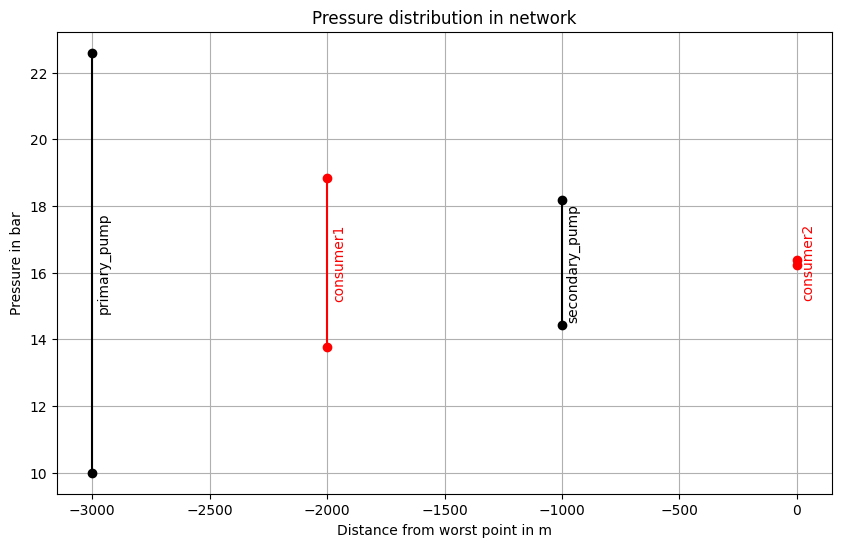

In [9]:
class NetworkxEvaluation:
    def __init__(self, pipe, res_pipe, hx, res_hx):
        '''
        This class helps to evaluate pandapipes results by evaluating shortest path 
        :params pipe: net.pipe df from pandapipes
        :params res_pipe: net.res_pipe df from pandapipes
        :params hx: net.heat_consumer df from pandapipes
        :params res_hx: net.res_heat_consumer df from pandapipes
        '''
        self.pipe = pipe
        self.res_pipe = res_pipe
        self.hx = hx
        self.res_hx = res_hx

        # Create dictionary from pipe data
        dict_pipe = {}
        
        for index, row in self.res_pipe.iterrows():
            length_km = self.pipe.loc[index]['length_km']
            length_m = length_km * 1000
            velocity = self.res_pipe.loc[index].v_mean_m_per_s
            junction_in = self.pipe.loc[index]['to_junction']
            junction_out = self.pipe.loc[index]['from_junction']
            
            dict_pipe[index] = {
                'junction_in': junction_in,
                'junction_out': junction_out,
                'length_m': length_m,
                'velocity_m_s': velocity,
                'pipe_no': index
            }

        self.G_undirected = nx.Graph()

        # Add edges to graph based on flow direction, without velocity

        for row in dict_pipe.values():
            # Add edge without velocity
            self.G_undirected.add_edge(row['junction_in'], row['junction_out'], 
                                        length_m=row['length_m'], pipe_no=row['pipe_no'])

    def find_shortest_path(self, start_junction, end_junction):
        '''
        Calculates shortest path 
        :params start_junction: Junction id of heat consumer
        :params end_junction: Junction id of producer
        :returns: Shortest directed path and path length between the two juctions, if path exists
        '''
                
        # Find the shortest path in directed graph
        try:
            # Calculate shortest direct path between the two junctions
            directed_path = nx.shortest_path(self.G_undirected, source=start_junction, target=end_junction, weight='length_m')
            directed_path_length = nx.shortest_path_length(self.G_undirected, source=start_junction, target=end_junction, weight='length_m')

        except nx.NetworkXNoPath:
            directed_path = None  # No direct path could be found
            directed_path_length = None

        return directed_path, directed_path_length

dp_min, idx_min = BadPointPressureLiftController.calculate_worst_point(net)
NxEval = NetworkxEvaluation(net.pipe, net.res_pipe, net.heat_consumer, net.res_heat_consumer)
badpoint_junction = net.heat_consumer.loc[idx_min,'from_junction']

# Dictionary with distance from worst point, inlet and outlet pressure by component
comp_dict ={}

for index, row in net.heat_consumer.iterrows():
    junction_supply = row['from_junction']
    path, length = NxEval.find_shortest_path(badpoint_junction,junction_supply)
    comp_dict[row['name']] ={}
    comp_dict[row['name']]['junction_supply'] = row['from_junction']
    comp_dict[row['name']]['junction_return'] = row['to_junction']
    comp_dict[row['name']]['distance'] = length
    comp_dict[row['name']]['p_supply_bar'] = net.res_heat_consumer.loc[index,'p_from_bar']
    comp_dict[row['name']]['p_return_bar'] = net.res_heat_consumer.loc[index,'p_to_bar']

for index, row in net.circ_pump_mass.iterrows():
    # select flow_control component that is connected to circ_pump_const_mass component
    flow_control = net.flow_control[net.flow_control['from_junction'] == row['flow_junction']]
    # Evaluation od supply pressure by taking pressure at outlet of flow control component
    junction_supply = flow_control.iloc[0]['to_junction']
    path, length = NxEval.find_shortest_path(badpoint_junction,junction_supply)
    comp_dict[row['name']] ={}
    comp_dict[row['name']]['junction_supply'] = flow_control.iloc[0]['to_junction']
    comp_dict[row['name']]['junction_return'] = row['return_junction']
    comp_dict[row['name']]['distance'] = length
    comp_dict[row['name']]['p_supply_bar'] = net.res_flow_control.loc[flow_control.index[0],'p_to_bar']
    comp_dict[row['name']]['p_return_bar'] = net.res_circ_pump_mass.loc[index,'p_from_bar']

# primary (pressure) pump
row = net.circ_pump_pressure.loc[0]
junction_supply = row['flow_junction']
path, length = NxEval.find_shortest_path(badpoint_junction,junction_supply)
comp_dict[row['name']] ={}
comp_dict[row['name']]['junction_supply'] = row['flow_junction']
comp_dict[row['name']]['junction_return'] = row['return_junction']
comp_dict[row['name']]['distance'] = length
comp_dict[row['name']]['p_supply_bar'] = net.res_circ_pump_pressure.loc[index,'p_to_bar']
comp_dict[row['name']]['p_return_bar'] = net.res_circ_pump_pressure.loc[index,'p_from_bar']

# Create the plot
plt.figure(figsize=(10, 6))

# Loop through each component in the dictionary
for component_name, component in comp_dict.items():
    distance = component['distance']*(-1)
    p_return_bar = component['p_return_bar']
    p_supply_bar = component['p_supply_bar']
    if 'consumer' in component_name:
        color = 'red'
    else:
        color = 'black'

    # Draw a vertical line from (distance, pressure_from) to (distance, pressure_to)
    plt.plot([distance, distance], [p_return_bar, p_supply_bar], marker='o', color = color)
    # Add label beside the line
    plt.text(distance + 20, (p_return_bar + p_supply_bar) / 2, component_name, color=color, rotation = 90, va = 'center')


plt.xlabel('Distance from worst point in m')
plt.ylabel('Pressure in bar')
plt.title('Pressure distribution in network')
plt.grid()

# Show plot
plt.show()